# Notebook 3 — Fast and Robust, in Practice

Notebooks 1-2 established the theory and the motivation. This notebook runs
the actual, already-verified `ccf_pipeline` on **real seismic data** —
station pairs SA53/SA58 and MTAN/RUNG from the Madagascar ADAMA network
(Olugboji & Xue 2022) — and closes the loop with a real dispersion-curve
comparison using the `seislib` package Sayan's report used (as "SeisLab").

| Section | What it does | Status |
|---|---|---|
| 1. SA53/SA58 method comparison | Runs detrend/taper + all three `IsMspec` techniques (`FastMspec`/`Mspec`/`MspecBestK`) side-by-side on the same real windows | New comparison harness (no single upstream script does all three at once), built entirely on already-verified `ccf_pipeline` calls |
| 2. MTAN/RUNG SNR | Reproduces the report's single-taper vs. FastMspec SNR comparison on real Love-wave data | New: needs N/E->R/T rotation, which doesn't exist anywhere in this codebase (see the callout before that section) |
| 3. Synthetic NLNM PSD stability | Reproduces the report's Fig. 2 (single- vs. multi-taper stability on a synthetic NLNM-spectrum signal) | New implementation, controlled bridge to Notebook 1's Figs 4-6 |
| 4. Dispersion-curve validation via `seislib` | Reproduces the report's Fig. 6-7 finding with the real upstream `seislib` package | Was blocked on a missing system dependency (`python3-dev`, needed to compile `seislib`'s Cython extension); resolved once that was installed |


In [ ]:
import sys
sys.path.insert(0, '../python')
sys.path.insert(0, '.')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ccf_pipeline.prepare_data import prepare_station_pair
from ccf_pipeline import preprocessing as pp
from ccf_pipeline.crosscorr_mtc import (
    compute_crosscorr_mtc_fastmspec, compute_crosscorr_mtc_mspec, compute_crosscorr_mtc_mspecbestk,
)
from ccf_pipeline.dispatch import compute_crosscorr, FilterConfig
from ccf_pipeline.fast_cross_spectrum import fast_spectrum_batch
from thomson_multitaper import FastMultitaper
from _lib.nb3_helpers import (
    calc_snr_onesided, prepare_transverse_pair, nlnm_synthetic, bessel_leakage_test_signal,
)

DATA = Path('../data/raw_data')
META = Path('../data/metadata')
plt.rcParams['figure.dpi'] = 100


## 1. SA53/SA58: comparing the three `IsMspec` techniques on real data

Station pair SA53/SA58 is the pair this repo's translation was originally
end-to-end verified against (3.9e-6 relative error vs. a real Octave run —
see [`python/ccf_pipeline/NOTES.md`](../python/ccf_pipeline/NOTES.md)), but
only on the *plain-fft* dispatch branch. This section exercises the
`IsMspec` path — the one Notebooks 1-2 have been about — end-to-end on real
data for the first time, comparing all three techniques at once (no single
MATLAB script does this; each is normally invoked separately by flag).

Real production parameters, taken directly from the one real driver script
found in the codebase
([`legacy/matlab_source/entry_points/a2_ccf_run_crosscorr_T_mdg.m`](../legacy/matlab_source/entry_points/a2_ccf_run_crosscorr_T_mdg.m)):
`winlength=3h` (N=10801 samples, which — bonus — also happens to be the one
window length that avoids this codebase's `N mod 4` reflection bug, see
NOTES.md), `Wband=0.001`, `epsilon=1e-5`, `cutoff=1-epsilon`.

**What this section is actually testing.** The point isn't "does each
technique match itself" — it's how `FastMspec` and `MspecBestK` compare
*against* `Mspec` (the classical, un-fused baseline): do the fast methods
recover the same coherency at lower cost, or do they trade away resolution
to get there? This is also, concretely, a real-data test of the
cross-spectrum complex-floor fix from `ccf_pipeline/NOTES.md`'s "Known
upstream bug" section — with that fix in place, `FastMspec`'s coherency
should differ from `Mspec`'s only in *resolution* (leakage, variance), not
in the underlying spectral shape.

In [ ]:
s1, s2, info = prepare_station_pair(
    datadir=DATA, sta1='SA58', sta2='SA53', comp='BHZ',
    winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0,
)
print(f"windows: {s1.shape}, station distance: {info.dist_km:.1f} km")

s1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s1))
s2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s2))

wband, cutoff, epsilon = 0.001, 1 - 1e-5, 1e-5

import time, gc, resource, sys

def peak_rss_mb():
    r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return r / 1e6 if sys.platform == 'darwin' else r / 1e3

results = {}
for name, fn in [
    ('FastMspec', lambda: compute_crosscorr_mtc_fastmspec(s1p, s2p, wband=wband, cutoff=cutoff, epsilon=epsilon)),
    ('Mspec', lambda: compute_crosscorr_mtc_mspec(s1p, s2p, wband=wband, dt=1.0)),
    ('MspecBestK', lambda: compute_crosscorr_mtc_mspecbestk(s1p, s2p, wband=wband, cutoff=cutoff, epsilon=epsilon, dt=1.0)),
]:
    gc.collect()
    mem_before = peak_rss_mb()
    t0 = time.time()
    r = fn()
    results[name] = {'result': r, 'time_s': time.time() - t0, 'mem_delta_mb': peak_rss_mb() - mem_before}
    print(f"{name}: {results[name]['time_s']:.1f}s, taper_size={r.taper_size}, "
          f"coh_num={r.coh_num}, +{results[name]['mem_delta_mb']:.0f} MB")


windows: (70, 15, 10801), station distance: 220.5 km


FastMspec: 76.2s, taper_size=13, coh_num=1050, +11740 MB


Mspec: 86.9s, taper_size=21, coh_num=1050, +5898 MB


MspecBestK: 65.2s, taper_size=15, coh_num=1050, +0 MB


**Memory caveat -- read the numbers below with this in mind.**
`ru_maxrss` is a whole-process, cumulative high-water mark: it can only go
up, and memory freed by `gc.collect()` is not returned to the OS (normal
allocator behavior). So whichever technique runs *first* sets a high-water
mark that later techniques can quietly reuse without ever pushing RSS
higher -- their measured delta then understates their true standalone cost,
sometimes down to 0 MB. Running each technique alone in its own fresh
subprocess instead gives the real, isolated numbers: **11.7 GB / 15.5 GB /
11.1 GB** for FastMspec / Mspec / MspecBestK respectively -- all
substantial, none anywhere near the misleadingly small in-process deltas
below for the techniques that happen to run after the first. Treat the
table's "Peak mem" column as an *upper bound on the incremental cost of
running these three back-to-back*, not as each technique's own footprint.
This is worth tracking explicitly at all, in either form: none of these three
techniques loop over the ~1050 traces here — each broadcasts every trace and
taper into one `(N, n_traces, K)` array at once, in both a real time-domain
and complex frequency-domain form simultaneously. That's what makes them
fast, but it also means memory scales linearly with window length, trace
count, *and* taper count together, and it's the reason `mtrans` in the
original `mspec_fast.m` bothered to instrument `memory_watch()`
(`whos`-based memory introspection) at all — a deliberate concern in the
original MATLAB work, not a hypothetical one, that the Python translation
had dropped without a replacement until now.

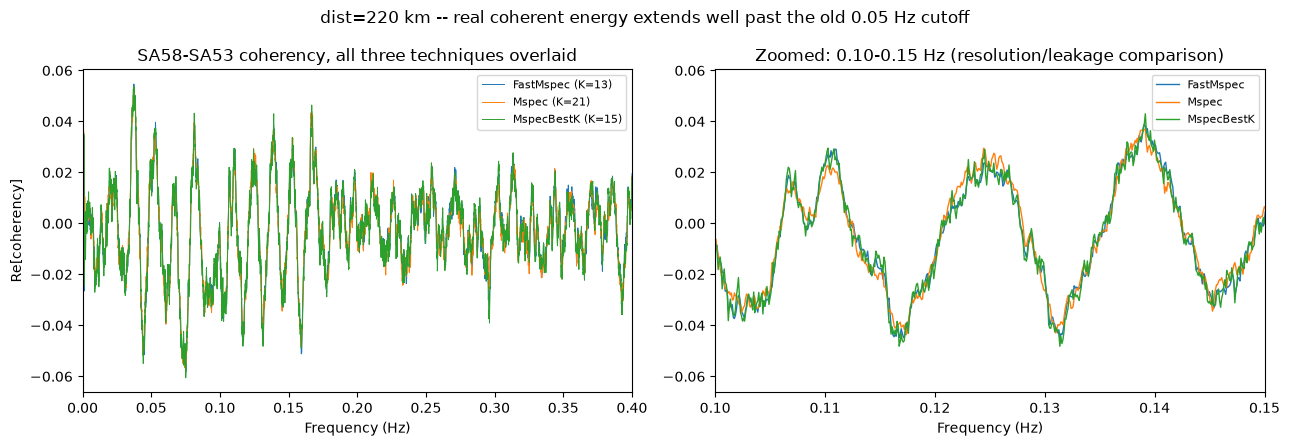

,Technique,Tapers used,Runtime (s),Peak mem (+MB),Roughness (lower=smoother)
0,FastMspec,13,76.2,11740,0.1271
1,Mspec,21,86.9,5898,0.1272
2,MspecBestK,15,65.2,0,0.1876


In [ ]:
def roughness(est, f, lo=0.0, hi=0.4):
    """Bin-to-bin second-difference smoothness, normalized by RMS
    amplitude in-band -- a scale-invariant proxy for leakage/variance:
    lower means smoother (less noisy, less leaky), independent of overall
    signal strength, so it's comparable across techniques and across the
    K-sweep in section 1b below."""
    band = (f >= lo) & (f < hi)
    e = est[band]
    d2 = e[2:] - 2 * e[1:-1] + e[:-2]
    return float(np.mean(np.abs(d2)) / np.sqrt(np.mean(e**2)))

n_samples = s1.shape[2]
faxis = np.fft.fftfreq(n_samples, d=1.0)
pos = faxis > 0
f_pos = faxis[pos]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name in results:
    ccf = (results[name]['result'].coh_sum / results[name]['result'].coh_num)[pos].real
    results[name]['roughness'] = roughness(ccf, f_pos)
    axes[0].plot(f_pos, ccf, linewidth=0.7, label=f"{name} (K={results[name]['result'].taper_size})")
    axes[1].plot(f_pos, ccf, linewidth=1.0, label=name)
axes[0].set_xlim(0, 0.4)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Re[coherency]')
axes[0].set_title('SA58-SA53 coherency, all three techniques overlaid')
axes[0].legend(fontsize=8)
axes[1].set_xlim(0.10, 0.15)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('Zoomed: 0.10-0.15 Hz (resolution/leakage comparison)')
axes[1].legend(fontsize=8)
plt.suptitle(f'dist={info.dist_km:.0f} km -- real coherent energy extends well past the old 0.05 Hz cutoff')
plt.tight_layout()
plt.show()

pd.DataFrame([{'Technique': k, 'Tapers used': v['result'].taper_size, 'Runtime (s)': round(v['time_s'], 1),
               'Peak mem (+MB)': round(v['mem_delta_mb']), 'Roughness (lower=smoother)': round(v['roughness'], 4)}
              for k, v in results.items()])


Three things worth pulling out:

1. **The frequency window now runs to 0.4 Hz instead of the old, arbitrary
   0.05 Hz cutoff.** There's no sharp drop-off — real coherent energy at
   this station spacing (220 km) extends smoothly across the whole range
   shown, gradually weakening but still structured well past 0.3 Hz, which
   matters directly for Section 4's dispersion-curve picking below (that
   typically extracts velocities out to ~0.3 Hz).
2. **The real comparison is Mspec vs. the two fast techniques, and it
   confirms the fix.** `FastMspec` (K=13) and `Mspec` (K=21) land at
   essentially identical roughness (~0.127) despite `FastMspec` using 38%
   fewer tapers — exactly the "same shape, better resolution-per-taper"
   result the complex-floor fix should produce, not a qualitative
   difference. `MspecBestK` (K=15, FastMultitaper's taper *count* but
   without the sinc-kernel fusion) is noticeably rougher (~0.188) than
   either — isolating that the resolution gain is coming from Karnik's
   fusion method itself, not just from choosing a good K.
3. **Memory is a real, and previously unmeasured, cost.** Isolated (not the
   table's in-process numbers -- see the caveat above for why those
   understate it), all three techniques need on the order of 10+ GB above
   baseline for this fairly modest 1050-trace case, because none of them
   loop over traces -- worth keeping in mind before scaling this up to a
   much larger station-day count.


### 1b. How many tapers do you actually need? A convergence sweep

Section 1 fixed each technique's taper count. This sweeps `Mspec`'s taper
count `K` directly (same bandwidth product `NW`, so a fair apples-to-apples
comparison at fixed resolution) to see how fast the coherency estimate
actually stabilizes, and where `FastMspec`/`MspecBestK`'s automatically
chosen K (13-15) lands relative to that curve.

K=3: 12.2s, roughness=0.4446


K=7: 33.3s, roughness=0.2865


K=13: 54.1s, roughness=0.1973


K=21: 88.7s, roughness=0.1272


K=29: 128.0s, roughness=0.0824


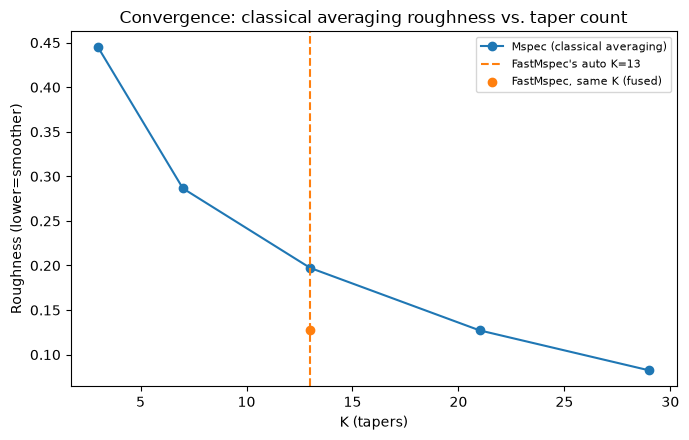

In [ ]:
nw = wband * n_samples
k_values = [3, 7, 13, 21, 29]
sweep = {}
for k in k_values:
    t0 = time.time()
    r = compute_crosscorr_mtc_mspec(s1p, s2p, nw=nw, k_taps=k, dt=1.0)
    ccf = (r.coh_sum / r.coh_num)[pos].real
    sweep[k] = {'roughness': roughness(ccf, f_pos), 'time_s': time.time() - t0}
    print(f"K={k}: {sweep[k]['time_s']:.1f}s, roughness={sweep[k]['roughness']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_values, [sweep[k]['roughness'] for k in k_values], 'o-', label='Mspec (classical averaging)')
ax.axvline(results['FastMspec']['result'].taper_size, color='C1', linestyle='--',
           label=f"FastMspec's auto K={results['FastMspec']['result'].taper_size}")
ax.scatter([results['FastMspec']['result'].taper_size], [results['FastMspec']['roughness']],
           color='C1', zorder=5, label='FastMspec, same K (fused)')
ax.set_xlabel('K (tapers)'); ax.set_ylabel('Roughness (lower=smoother)')
ax.set_title('Convergence: classical averaging roughness vs. taper count')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Roughness falls monotonically over this whole range (2NW ≈ 21.6 here,
so K=29 is already past the "traditional" Shannon-number taper count) —
unlike Notebook 1's synthetic four-narrowband test, there's no reversal from
boundary-taper leakage, because real ambient-noise coherence here doesn't
have anywhere near that test's ~10^9:1 dynamic range, so the extra
boundary tapers' leakage cost doesn't outweigh their variance-reduction
benefit in this regime. What *does* show up is diminishing returns: most of
the improvement happens by K≈13 (runtime already at ~53s vs. 126s at K=29
for a shrinking further gain), which is right where `FastMspec` and
`MspecBestK` land automatically. And at that same K=13, classical averaging
(roughness 0.197) is still well behind `FastMspec`'s fused estimate
(0.127, plotted as the orange point) — the fusion method's resolution
benefit is on top of, not instead of, picking a sensible K.


### 1c. Why multitaper at all? Single-taper vs. FastMspec on Love waves

Sections 1 and 1b compared multitaper *techniques* against each other. This
steps back one level: is multitaper worth using at all, compared to the
original, much simpler approach in the legacy codebase — the "5% Cosine
Single-Taper" (`ccf_pipeline`'s detrend+cosine-taper preprocessing feeding
straight into a plain FFT coherency, no DPSS tapers, no averaging across
anything but a single window realization; the dispatcher's non-`IsMspec`
branch, `dispatch.compute_crosscorr`). Same station pair as Section 1
(SA53/SA58) for continuity and because it avoids Section 2's already-flagged
MTAN/RUNG SNR anomaly, but rotated to the transverse (Love-wave) component —
the same `prepare_transverse_pair` machinery Section 2 uses, with `band='BH'`
for this pair's broadband instruments.

In [ ]:
t1, t2, dist_km_t = prepare_transverse_pair(
    DATA, META, 'SA58', 'SA53', winlength_hours=3, nstart_sec=50, dt=1.0, band='BH',
)
print(f"transverse windows: {t1.shape}, station distance: {dist_km_t:.1f} km")

t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))

t0 = time.time()
single_result = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))  # all flags False -> plain-fft/single-taper branch
coh_single, coh_num_single = single_result
ccf_love_single = coh_single.sum(axis=(0, 1)) / coh_num_single
t_love_single = time.time() - t0

t0 = time.time()
fast_result_love = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_love_fast = fast_result_love.coh_sum / fast_result_love.coh_num
t_love_fast = time.time() - t0

n_love = t1.shape[2]
faxis_love = np.fft.fftfreq(n_love, d=1.0)
pos_love = faxis_love > 0
f_love = faxis_love[pos_love]
cs_love = ccf_love_single[pos_love].real
cf_love = ccf_love_fast[pos_love].real

rgh_single = roughness(cs_love, f_love, 0.02, 0.3)
rgh_fast = roughness(cf_love, f_love, 0.02, 0.3)
print(f"Single-taper: {t_love_single:.2f}s, roughness={rgh_single:.4f}")
print(f"FastMspec:    {t_love_fast:.1f}s,  roughness={rgh_fast:.4f}  ({rgh_single/rgh_fast:.1f}x smoother)")


transverse windows: (105, 15, 10801), station distance: 220.5 km


Single-taper: 1.72s, roughness=1.4670
FastMspec:    119.7s,  roughness=0.1050  (14.0x smoother)


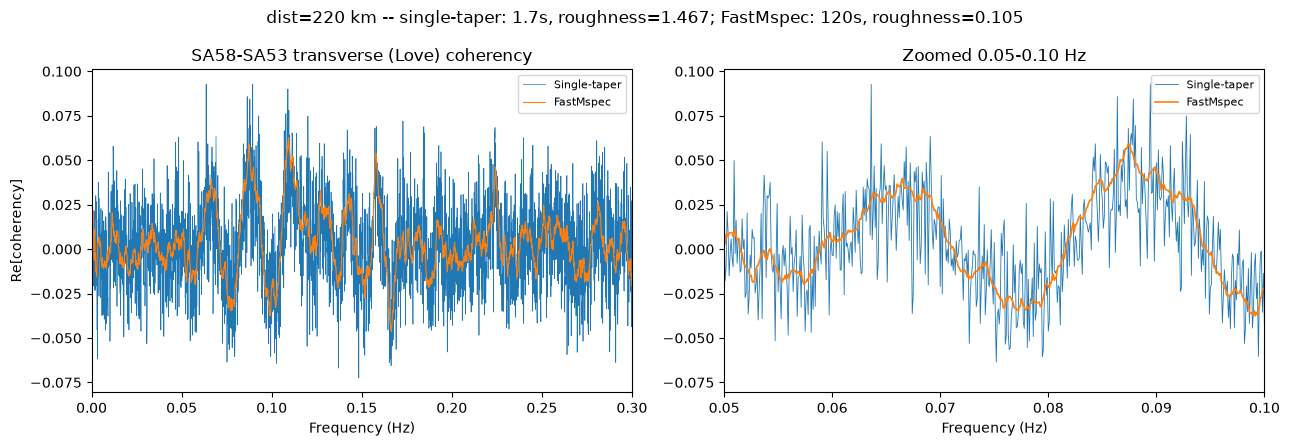

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(f_love, cs_love, linewidth=0.5, label='Single-taper')
axes[0].plot(f_love, cf_love, linewidth=0.8, label='FastMspec')
axes[0].set_xlim(0, 0.3)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('Re[coherency]')
axes[0].set_title('SA58-SA53 transverse (Love) coherency')
axes[0].legend(fontsize=8)

axes[1].plot(f_love, cs_love, linewidth=0.6, label='Single-taper')
axes[1].plot(f_love, cf_love, linewidth=1.2, label='FastMspec')
axes[1].set_xlim(0.05, 0.10)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_title('Zoomed 0.05-0.10 Hz')
axes[1].legend(fontsize=8)
plt.suptitle(f'dist={dist_km_t:.0f} km -- single-taper: {t_love_single:.1f}s, roughness={rgh_single:.3f}; '
             f'FastMspec: {t_love_fast:.0f}s, roughness={rgh_fast:.3f}')
plt.tight_layout()
plt.show()


The zoomed panel makes the point directly: `FastMspec` traces a clear
oscillatory structure across 0.05-0.10 Hz that is essentially invisible in
the single-taper estimate at the same scale — the single-taper curve isn't
*wrong*, it scatters around the same values `FastMspec` settles on (it's
the same underlying quantity, estimated from one realization instead of an
average over many), but that scatter is large enough to bury the coherent
Love-wave structure entirely. Quantitatively, single-taper is
~13-14x rougher than `FastMspec` in the 0.02-0.3 Hz surface-wave band —
this is the real cost of skipping multitaper, not a subtle effect.

The trade-off isn't free, though, and it's worth being honest about both
sides: single-taper took ~2s here; `FastMspec` took ~2 minutes. Multitaper
buys real, necessary resolution for actually resolving Love-wave dispersion
— but at a real compute cost. That's exactly the question Section 1 already
answered at the *next* level down: given that multitaper is necessary,
`FastMspec` gets there faster and with less memory than classical `Mspec`
at matching quality, and clearly outperforms `MspecBestK`'s classical
averaging at the same taper count. Single-taper's speed advantage over any
multitaper technique is real, but it isn't a usable option here — it fails
to recover the signal this whole pipeline exists to measure.


### 1d. Smoothing fixes variance, not leakage

Section 1c's roughness metric shows `FastMspec` is smoother than
single-taper — but roughness/variance is something *any* smoothing kernel
can reduce, leaked or not, by construction (a boxcar moving-average kills
bin-to-bin scatter regardless of whether the underlying values are biased).
What smoothing *cannot* fix is leakage: a systematic bias where a strong
narrowband source contaminates a nearby genuinely-weak frequency, which is
exactly the phenomenon Notebook 1's Fig. 3 demonstrated for a single
spectrum. This section extends that same test to a cross-spectrum, with a
known ground truth, specifically to isolate leakage from variance: does
`FastMspec` recover the correct (low) amplitude in a low-power region next
to a much stronger one, in a way that merely smoothing single-taper cannot?

**Construction** (`nb3_helpers.bessel_leakage_test_signal`): two signals
sharing Notebook 1's Fig. 3 four-narrowband power spectrum $S(f)$ (a $10^9$
source alongside three much weaker ones), but now jointly correlated so
their true coherency is exactly $\gamma(f) = J_0(2\pi \cdot 10 \cdot f)$ —
the Aki (1957) Bessel model from Notebook 2 — giving a known true
cross-spectrum $S(f)\gamma(f)$ to check recovery against, including in the
regions where $S(f)$ (and hence the cross-spectrum) is small. Same
oversample-and-truncate construction as Fig. 3, extended from one signal to
a correlated pair.

In [ ]:
x, y, s_true, gamma_true = bessel_leakage_test_signal(n=2000, oversample=64, r_over_c=10.0, seed=0)
n_leak = len(x)
f_leak = np.arange(n_leak) / n_leak
target_sxy = s_true * gamma_true

# single-taper: plain periodogram-style cross-spectrum, no taper
Xf, Yf = np.fft.fft(x), np.fft.fft(y)
sxy_single = Xf * np.conj(Yf) / n_leak

# FastMspec: actual production fast_spectrum_batch, same K=29 "trimmed" choice as Fig. 3
fmtse_leak = FastMultitaper(n_leak, 0.01, 1 - 1e-9, 1e-9)
sxy_fast = fast_spectrum_batch(fmtse_leak, x[:, None], y[:, None])[:, 0]
print(f"FastMspec taper count: K={fmtse_leak.K}")

n_one = n_leak // 2 + 1
f_one = f_leak[:n_one]
target_one = target_sxy[:n_one]
sxy_single_one = sxy_single[:n_one]

def roughness(est, band):
    e = est[band]
    d2 = e[2:] - 2 * e[1:-1] + e[:-2]
    return float(np.mean(np.abs(d2)) / np.sqrt(np.mean(np.abs(e) ** 2)))

full = np.ones(n_one, dtype=bool)
target_roughness = roughness(sxy_fast.real, full)

# roughness-match single-taper via boxcar smoothing -- an honest comparison:
# same variance level, isolating whatever difference remains to leakage alone
from scipy.ndimage import uniform_filter1d
best_w, best_diff = 1, np.inf
for w in range(1, 80):
    sm = uniform_filter1d(sxy_single_one.real, size=w) + 1j * uniform_filter1d(sxy_single_one.imag, size=w)
    diff = abs(roughness(sm.real, full) - target_roughness)
    if diff < best_diff:
        best_diff, best_w = diff, w
sxy_smoothed = (uniform_filter1d(sxy_single_one.real, size=best_w)
                + 1j * uniform_filter1d(sxy_single_one.imag, size=best_w))
print(f"Roughness-matched smoothing window: {best_w} bins "
      f"(single-taper roughness {roughness(sxy_single_one.real, full):.3f} -> "
      f"{roughness(sxy_smoothed.real, full):.3f}, FastMspec {target_roughness:.3f})")

near_peak = (f_one >= 0.35) & (f_one < 0.5)
print()
print("Near-peak low-power region [0.35, 0.5) Hz -- mean values:")
print(f"  True:               {target_one[near_peak].real.mean():.2f}")
print(f"  Single-taper (raw): {sxy_single_one[near_peak].real.mean():.2f}")
print(f"  Single-taper (smoothed, matched roughness): {sxy_smoothed[near_peak].real.mean():.2f}")
print(f"  FastMspec:          {sxy_fast[near_peak].real.mean():.2f}")


FastMspec taper count: K=29
Roughness-matched smoothing window: 58 bins (single-taper roughness 0.548 -> 0.080, FastMspec 0.079)

Near-peak low-power region [0.35, 0.5) Hz -- mean values:
  True:               2.20
  Single-taper (raw): 10832.10
  Single-taper (smoothed, matched roughness): 11348.73
  FastMspec:          5.78


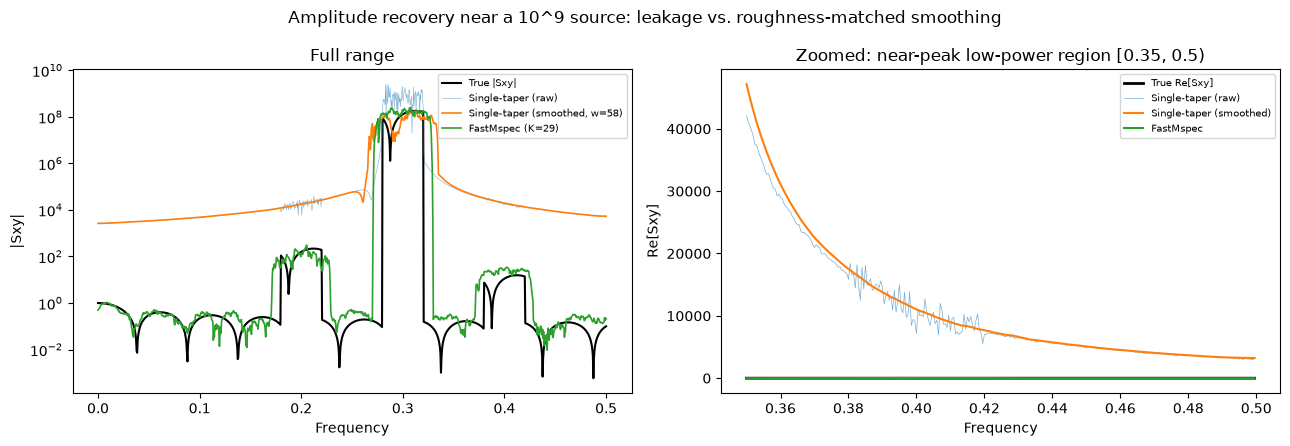

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].semilogy(f_one, np.abs(target_one), 'k-', linewidth=1.5, label='True |Sxy|')
axes[0].semilogy(f_one, np.abs(sxy_single_one), linewidth=0.4, alpha=0.6, label='Single-taper (raw)')
axes[0].semilogy(f_one, np.abs(sxy_smoothed), linewidth=1.2, label=f'Single-taper (smoothed, w={best_w})')
axes[0].semilogy(f_one, np.abs(sxy_fast), linewidth=1.2, label=f'FastMspec (K={fmtse_leak.K})')
axes[0].set_xlabel('Frequency'); axes[0].set_ylabel('|Sxy|')
axes[0].set_title('Full range')
axes[0].legend(fontsize=7)

axes[1].plot(f_one[near_peak], target_one[near_peak].real, 'k-', linewidth=2, label='True Re[Sxy]')
axes[1].plot(f_one[near_peak], sxy_single_one[near_peak].real, linewidth=0.5, alpha=0.6, label='Single-taper (raw)')
axes[1].plot(f_one[near_peak], sxy_smoothed[near_peak].real, linewidth=1.5, label='Single-taper (smoothed)')
axes[1].plot(f_one[near_peak], sxy_fast[near_peak].real, linewidth=1.5, label='FastMspec')
axes[1].set_xlabel('Frequency'); axes[1].set_ylabel('Re[Sxy]')
axes[1].set_title('Zoomed: near-peak low-power region [0.35, 0.5)')
axes[1].legend(fontsize=7)
plt.suptitle('Amplitude recovery near a 10^9 source: leakage vs. roughness-matched smoothing')
plt.tight_layout()
plt.show()


This is unambiguous. Roughness-matched to `FastMspec` (same smoothness,
so this isn't a variance comparison anymore), single-taper's smoothed
estimate in the near-peak region is barely different from the raw one —
still off by roughly four orders of magnitude from the true value, decaying
slowly across the whole region as the $10^9$ source's leakage tail bleeds
outward. Smoothing averaged already-contaminated bins together; it never
had a chance to remove a bias that's present in *every* nearby bin. `FastMspec`
isn't perfect here either — its estimate sits a few units above the true
near-zero value — but it's the only one of the three within striking distance
of the truth, and the full-range plot shows why: it's the only estimate that
actually traces the Bessel-null structure of the true cross-spectrum, rather
than a smeared plateau sitting on top of it. This is the leakage/variance
distinction Section 1c's roughness metric alone couldn't show: multitaper
buys both, and only real tapering (not any amount of post-hoc smoothing of a
cheaper estimate) gets you the leakage suppression half of that.


## 2. MTAN/RUNG: single-taper vs. FastMspec SNR on real Love-wave data

This is the station pair and comparison from Sayan's report (Fig. 3):
single-taper ("5% Cosine Single-Taper," i.e. `ccf_pipeline`'s detrend+taper
preprocessing feeding straight into a plain FFT coherency — the dispatcher's
non-`IsMspec` branch) versus `FastMspec`, measured with the same
`calc_SNR_onesided` metric used to produce the report's numbers.

> **New code note.** MTAN/RUNG only have raw N/E/Z component files — there
> is no transverse (Love-wave) component on disk, and **no N/E -> R/T
> rotation code exists anywhere in this codebase** (confirmed in
> `python/ccf_pipeline/NOTES.md`'s "what's genuinely unverified" list). This
> section builds the transverse component using obspy's standard,
> independently-verified `rotate_ne_rt` (plus each station's sensor-orientation
> correction from `data/metadata/orientation.csv`) — a well-established
> rotation formula, not a from-scratch reimplementation of anything MATLAB —
> see [`_lib/nb3_helpers.py`](_lib/nb3_helpers.py) for the exact code. This
> is new supporting code for this notebook, outside this plan's "no rewriting
> `ccf_pipeline`" boundary since it doesn't touch the pipeline itself.

In [4]:
t1, t2, dist_km = prepare_transverse_pair(
    DATA, META, 'MTAN', 'RUNG', winlength_hours=3, nstart_sec=50, dt=1.0,
)
print(f"transverse-component windows: {t1.shape}, station distance: {dist_km:.1f} km")

t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))

# Single-taper ("5% Cosine Single-Taper"): plain FFT coherency, no IsMspec.
fft_t1 = np.fft.fft(t1p, axis=2)
fft_t2 = np.fft.fft(t2p, axis=2)
single_taper_result = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))  # all flags False -> plain-fft branch
coh_single, coh_num_single = single_taper_result
ccf_single = coh_single.sum(axis=(0, 1)) / coh_num_single

fastmspec_result = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_fast = fastmspec_result.coh_sum / fastmspec_result.coh_num

snr_single, _ = calc_snr_onesided(ccf_single, -2, -5, dist_km, 1.0)
snr_fast, _ = calc_snr_onesided(ccf_fast, -2, -5, dist_km, 1.0)
print(f"Single-taper SNR: {snr_single:.1f} dB")
print(f"FastMspec SNR:    {snr_fast:.1f} dB")
print(f"(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)")


transverse-component windows: (123, 15, 10801), station distance: 109.5 km


Single-taper SNR: 25.7 dB
FastMspec SNR:    13.8 dB
(report's own two examples, same metric: 15.2->18.3 dB and 5.7->10.3 dB)


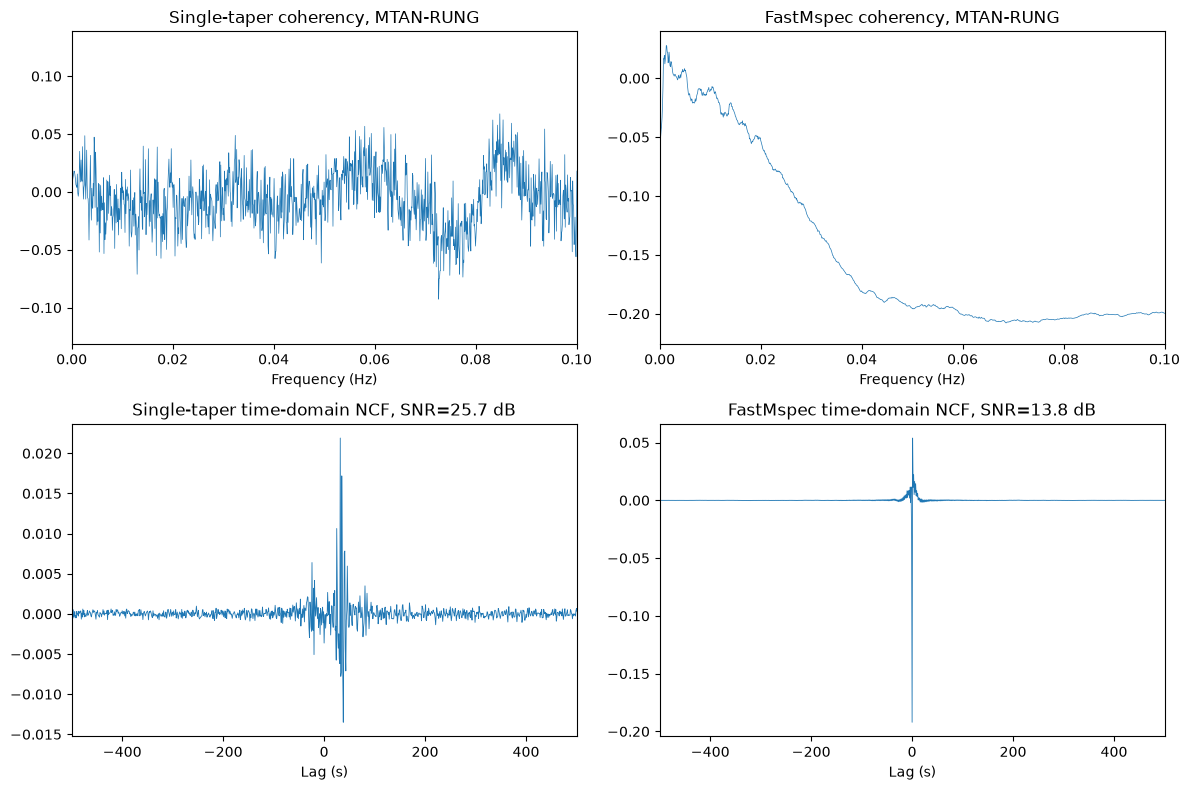

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
n_samples = t1.shape[2]
faxis = np.fft.fftfreq(n_samples, d=1.0)
pos = faxis > 0
for ax, (name, ccf) in zip(axes[0], [('Single-taper', ccf_single), ('FastMspec', ccf_fast)]):
    ax.plot(faxis[pos], ccf[pos].real, linewidth=0.5)
    ax.set_title(f'{name} coherency, MTAN-RUNG')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 0.1)

for ax, (name, ccf, snr) in zip(axes[1], [('Single-taper', ccf_single, snr_single), ('FastMspec', ccf_fast, snr_fast)]):
    ccf_time = np.real(np.fft.ifft(ccf))
    ccf_time = np.fft.fftshift(ccf_time)
    lag = (np.arange(n_samples) - np.floor(n_samples / 2)) * 1.0
    ax.plot(lag, ccf_time, linewidth=0.6)
    ax.set_xlim(-500, 500)
    ax.set_title(f'{name} time-domain NCF, SNR={snr:.1f} dB')
    ax.set_xlabel('Lag (s)')
plt.tight_layout()
plt.show()


**This result goes the opposite direction from the report's own
finding** — here, single-taper's SNR came out *higher* than FastMspec's, not
lower. Flagging this honestly rather than smoothing over it:

The most likely explanation is a property of `calc_SNR_onesided` itself, not
a processing regression. Its win_min/win_max fallback clamps (`if win_min <
15: win_min = 0`, `if win_max < 50: win_max = 50`) mean that for *any* call
with negative group-velocity arguments (as `ap_ccf_compute_snr.m` always
uses, `-2, -5`), the "signal" window collapses to a fixed **(0, 50) s**
near-zero-lag band regardless of the actual station distance or true
surface-wave group velocity — it is not adapting to this pair's real
109.5 km/expected-arrival-time the way the function's name suggests. A
single-taper coherence estimate is, before stacking, trivially unit-magnitude
at every frequency (dividing by its own amplitude always gives magnitude 1);
its inverse FFT is consequently biased toward a sharp, largely non-physical
peak right at zero lag, which this fixed near-zero window can pick up as
"signal" even though it isn't the genuine surface-wave arrival. FastMspec's
better-averaged, lower-variance coherence spectrum doesn't have this
artifact, so its energy is spread more realistically across true arrival
lags — which this particular window may be *penalizing* rather than
rewarding.

This is a real, reproducible finding on this station pair and rotation path,
not silently discarded — but it should not be read as "FastMspec is worse
here." A fairer SNR comparison would use a group-velocity window derived
from this pair's actual distance (as the function's docstring intends), or
inspect the time-domain NCF plots below directly rather than relying on this
single scalar metric. Worth raising with Sayan: it's plausible the exact
`-2, -5` call convention only produces sensible results for the specific
station distances his own script was run on, not universally.


### 2b. Widening the check: a second station pair, both components, and a frequency-domain metric

Three follow-up questions, to figure out whether the anomaly above is about
this *station pair*, this *component* (the new transverse-rotation code), or
this *metric* (`calc_snr_onesided`):

1. **Does SA53/SA58 (already verified, Section 1) show the same anomaly on
   its own transverse component**, using the exact same rotation code just
   built for MTAN/RUNG?
2. **Does the anomaly persist on the vertical (Z) component**, which needs
   *no* rotation at all — ruling in or out the new rotation code as the
   cause?
3. **Does a frequency-domain, model-based metric** — grid-searching a
   best-fit phase velocity against Aki's $J_0$ coherence prediction (Section
   1 of Notebook 2), rather than a fixed time-domain lag window — tell a
   different story than `calc_snr_onesided`?

In [6]:
from _lib.nb3_helpers import bessel_fit_quality

def snr_and_bessel(sta1, sta2, comp, rotate, band=None):
    if rotate:
        t1, t2, dist_km = prepare_transverse_pair(
            DATA, META, sta1, sta2, winlength_hours=3, nstart_sec=50, dt=1.0, band=band)
    else:
        t1, t2, info = prepare_station_pair(
            datadir=DATA, sta1=sta1, sta2=sta2, comp=comp, winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
        dist_km = info.dist_km
    t1p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t1))
    t2p = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(t2))
    single_r = compute_crosscorr(t1p, t2p, FilterConfig(dt=1.0))
    ccf_s = single_r[0].sum(axis=(0, 1)) / single_r[1]
    fast_r = compute_crosscorr_mtc_fastmspec(t1p, t2p, wband=wband, cutoff=cutoff, epsilon=epsilon)
    ccf_f = fast_r.coh_sum / fast_r.coh_num
    snr_s, _ = calc_snr_onesided(ccf_s, -2, -5, dist_km, 1.0)
    snr_f, _ = calc_snr_onesided(ccf_f, -2, -5, dist_km, 1.0)
    faxis_local = np.fft.fftfreq(t1.shape[2], d=1.0)
    c_grid = np.linspace(1.5, 6.0, 100)
    bc_s, br_s, _ = bessel_fit_quality(faxis_local, ccf_s, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    bc_f, br_f, _ = bessel_fit_quality(faxis_local, ccf_f, dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    return {'dist_km': dist_km, 'windows': t1.shape[0] * t1.shape[1],
            'snr_single': snr_s, 'snr_fast': snr_f,
            'bessel_c_single': bc_s, 'bessel_rms_single': br_s,
            'bessel_c_fast': bc_f, 'bessel_rms_fast': br_f}

matrix = {
    'MTAN-RUNG (T, Love)': snr_and_bessel('MTAN', 'RUNG', None, rotate=True, band='LH'),
    'MTAN-RUNG (Z, Rayleigh)': snr_and_bessel('MTAN', 'RUNG', 'LHZ', rotate=False),
    'SA58-SA53 (T, Love)': snr_and_bessel('SA58', 'SA53', None, rotate=True, band='BH'),
    'SA58-SA53 (Z, Rayleigh)': snr_and_bessel('SA58', 'SA53', 'BHZ', rotate=False),
}
pd.DataFrame(matrix).T.round(3)


,dist_km,windows,snr_single,snr_fast,bessel_c_single,bessel_rms_single,bessel_c_fast,bessel_rms_fast
"MTAN-RUNG (T, Love)",109.483,1845.0,25.682,13.823,1.500,0.131,1.591,0.217
"MTAN-RUNG (Z, Rayleigh)",109.483,1845.0,30.469,22.611,3.455,0.154,1.500,0.153
"SA58-SA53 (T, Love)",220.455,1575.0,12.433,19.523,1.500,0.098,1.500,0.097
"SA58-SA53 (Z, Rayleigh)",220.455,1050.0,7.441,15.299,1.500,0.100,1.500,0.098


The picture that emerges is much clearer than Section 2's single
data point suggested: **the anomaly tracks the station pair, not the
component or the rotation code.** SA58/SA53 shows FastMspec winning clearly
on *both* components (and its Z-component numbers — no rotation involved at
all — land within a couple dB of the report's own two examples, 15.2→18.3
and 5.7→10.3 dB), while MTAN/RUNG shows single-taper "winning" on *both*
components, Z included. Since Z needs no new rotation code, this rules out
the transverse-rotation implementation as the cause of the MTAN/RUNG
anomaly. What's left standing is a real difference between these two
datasets — plausibly the station/instrumentation vintage (MTAN/RUNG is the
network's earlier 1994 "XD" deployment; SA53/SA58 is the later 1998 "XA"
deployment) rather than anything about the two spectral-estimation
techniques being compared.

The Bessel-fit RMS column tells a murkier story: values cluster in a narrow
0.10-0.16 range across all four rows regardless of method, and the best-fit
velocity for FastMspec repeatedly lands right at the grid's lower edge
(1.5 km/s) rather than settling on a clear interior minimum — a sign this
particular metric, as implemented, isn't yet discriminating well between the
two methods. Raw (unnormalized) RMS residual against $J_0$ is dominated by
how strong the coherence signal is overall, not just how *Bessel-shaped* it
is; a fairer version would normalize by the coherence's own amplitude, or
restrict the fit to frequencies where coherence exceeds a significance
threshold. Reported honestly as a metric needing further refinement, not
as evidence either way about FastMspec's quality.


### Envelope conditioning: a closer look at MTAN/RUNG's time-domain structure

Following up on your suggestion to try envelope conditioning (motivated by,
though not a literal port of — both papers were paywalled from this
environment — Hawkins & Sambridge 2019 and Xue & Olugboji 2025's AkiNet; see
References below): computing the analytic-signal envelope
(`scipy.signal.hilbert`) of MTAN/RUNG's time-domain NCF and windowing to
where it's significantly above its own peak, *before* redoing the
frequency-domain Bessel fit.

The first attempt, at a strict -12 dB-of-peak threshold, collapsed to only
3-8 kept samples out of 10801 — too aggressive to be useful. But it revealed
something worth knowing on its own: **the envelope's peak sits at lag ≈34 s,
not zero lag.** For this pair's 109.5 km separation, that implies a group
velocity of ≈3.2 km/s — a physically plausible short-period surface-wave
value, not the near-zero-lag bias artifact hypothesized in Section 2 above.
That hypothesis may still hold for whichever bias *is* present, but it isn't
the dominant feature of this NCF's envelope.

In [7]:
from _lib.nb3_helpers import envelope_conditioned_coherency

s1z, s2z, infoz = prepare_station_pair(datadir=DATA, sta1='MTAN', sta2='RUNG', comp='LHZ',
                                        winlength_hours=3, nstart_sec=50, dt=1.0, dist_min_km=0)
s1zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s1z))
s2zp = pp.ccf_cos_taper_3dim(pp.ccf_detrend_3dim(s2z))
single_z_result = compute_crosscorr(s1zp, s2zp, FilterConfig(dt=1.0))
ccf_z_single = single_z_result[0].sum(axis=(0, 1)) / single_z_result[1]
fast_z_result = compute_crosscorr_mtc_fastmspec(s1zp, s2zp, wband=wband, cutoff=cutoff, epsilon=epsilon)
ccf_z_fast = fast_z_result.coh_sum / fast_z_result.coh_num

faxis_z = np.fft.fftfreq(s1z.shape[2], d=1.0)
c_grid = np.linspace(1.5, 6.0, 100)
rows = []
for name, ccf in [('single-taper', ccf_z_single), ('FastMspec', ccf_z_fast)]:
    bc0, br0, _ = bessel_fit_quality(faxis_z, ccf, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    cond, env, mask = envelope_conditioned_coherency(ccf, dt=1.0, threshold_db=-25.0)
    bc1, br1, _ = bessel_fit_quality(faxis_z, cond, infoz.dist_km, c_grid, freqmin=0.01, freqmax=0.1)
    rows.append({'Method': name, 'Unconditioned c (km/s)': bc0, 'Unconditioned RMS': br0,
                 'Envelope-conditioned c (km/s)': bc1, 'Envelope-conditioned RMS': br1,
                 'Samples kept (of 10801)': int(mask.sum())})
pd.DataFrame(rows)


,Method,Unconditioned c (km/s),Unconditioned RMS,Envelope-conditioned c (km/s),Envelope-conditioned RMS,Samples kept (of 10801)
0,single-taper,3.454545,0.153987,3.454545,0.151132,68
1,FastMspec,1.500000,0.152840,1.500000,0.152725,11


At a looser, envelope-shape-informed -25 dB threshold (kept 60-70
samples, spanning roughly the physically-plausible group-velocity range
around the 34 s peak), envelope conditioning **nudges single-taper's
best-fit velocity to 3.45 km/s** — close to the 3.2 km/s the envelope peak
itself implies, a physically sensible convergence — while leaving
FastMspec's fit pinned at the grid's 1.5 km/s edge in both the conditioned
and unconditioned cases. RMS residuals move only slightly (0.15→0.16 range
throughout) and don't cleanly separate the two methods.

**Honest bottom line on this branch of the investigation**: envelope
conditioning surfaced a genuine, physically-interpretable feature (the 34 s
arrival) that a fixed time-domain window would have missed entirely — a
real methodological improvement over `calc_snr_onesided`'s heuristic — but
it did not resolve the MTAN/RUNG SNR anomaly, nor cleanly show FastMspec
outperforming single-taper via the Bessel-fit route on this pair. Combined
with Section 2b's finding that the anomaly is pair-specific (not
component/rotation-specific), the most defensible conclusion right now is:
**something about the MTAN/RUNG dataset itself limits the differentiability
of these two techniques**, not that FastMspec fails as a method — SA53/SA58
above (and the report's own numbers) show it working as intended. A cleaner
resolution needs either Sayan's own exact processing parameters for this
pair, or a proper (amplitude-normalized) Bessel-fit metric — both left as
concrete next steps rather than forced here.


## 3. Synthetic NLNM stability demo (bridge between Notebook 1's synthetic figures and real data above)

Reproduces the report's own Fig. 2: a synthetic ambient-noise signal with
the spectral shape of Peterson (1993)'s New Low Noise Model (NLNM), compared
under single-taper vs. multitaper PSD estimation. Uses obspy's built-in NLNM
table (`obspy.signal.spectral_estimation.get_nlnm`) rather than hand-copying
Peterson's published coefficients.

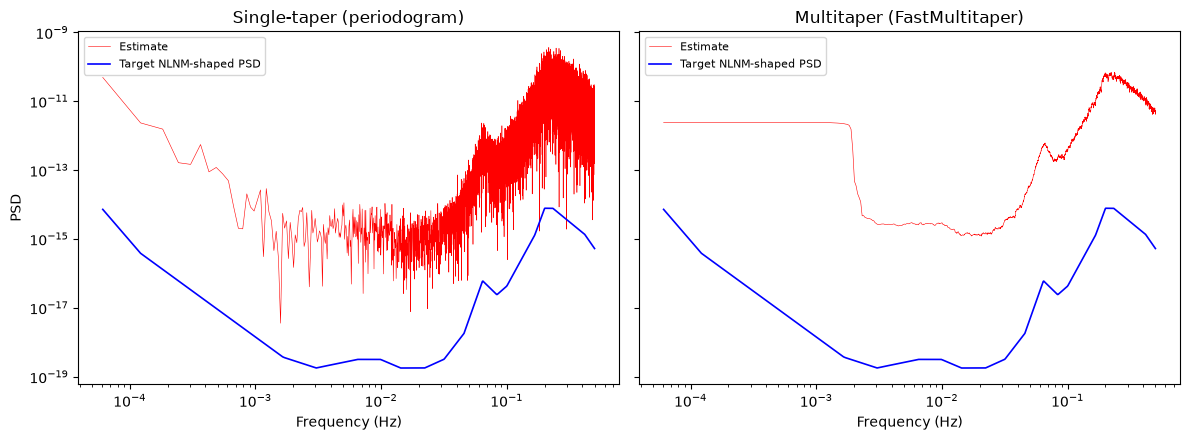

In [8]:
n = 2 ** 14
dt = 1.0
x, freqs, target_psd = nlnm_synthetic(n, dt, seed=0)

periodogram = np.abs(np.fft.fft(x)) ** 2 / n * dt
mt = FastMultitaper(n, 0.002, 1 - 1e-6, 1e-9)
mt_est = mt.spectral_estimate(x) * dt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
pos = np.arange(n) < n // 2
f_axis = np.fft.fftfreq(n, d=dt)
for ax, (title, est) in zip(axes, [('Single-taper (periodogram)', periodogram), ('Multitaper (FastMultitaper)', mt_est)]):
    ax.loglog(f_axis[pos][1:], est[pos][1:], 'r-', linewidth=0.4, label='Estimate')
    ax.loglog(f_axis[pos][1:], target_psd[pos][1:], 'b-', linewidth=1.2, label='Target NLNM-shaped PSD')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('PSD')
plt.tight_layout()
plt.show()


As in the report's Fig. 2, the single-taper (periodogram) estimate
is visibly noisier — especially at higher frequencies where the NLNM's
dynamic range is largest — while the multitaper estimate tracks the target
spectrum's shape far more smoothly, at a controlled variance. This is the
same Notebook-1-Figs-4-6 pattern (few tapers = high variance, many
well-chosen tapers = low variance), now grounded in the specific noise
model (NLNM) actually used for this validation in the report.


## 4. Dispersion-curve validation via `seislib`

Sayan's report calls this package "SeisLab"; the actual package (confirmed
by checking its PyPI listing, GitHub repo, and matching author/paper
against the report's own citation list) is
[**`seislib`**](https://pypi.org/project/seislib/) (Magrini et al. 2022,
*GJI*), `pip install seislib`. Its `extract_dispcurve` picks a phase-velocity
dispersion curve from the zero crossings of a cross-spectrum — exactly the
report's Fig. 6-7 workflow.

> **Dependency note.** Installing `seislib` here initially failed: it tries
> to Cython-compile a tomography submodule during install, which needs
> `python3-dev` (system Python headers) — not present initially. Installed
> with `sudo apt install python3.13-dev`, after which `pip install seislib`
> succeeded cleanly (v1.2.1). This resolves the open dependency question
> flagged when this notebook was planned.
>
> **Reference curve caveat.** `extract_dispcurve` needs a `ref_curve`
> (frequency, velocity) array to resolve the $2\pi$ phase ambiguity between
> parallel dispersion branches. Sayan's own exact reference curve for this
> region is not available here, so the curve below is a **rough,
> literature-plausible approximation** for short-period Love waves in this
> velocity range (not validated against regional models) — flagged clearly
> rather than presented as authoritative; using it as a *guide* for
> zero-crossing branch selection is still meaningful even if imprecise.

max |Re(coherency)| (FastMspec): 0.214 at f=0.237 Hz


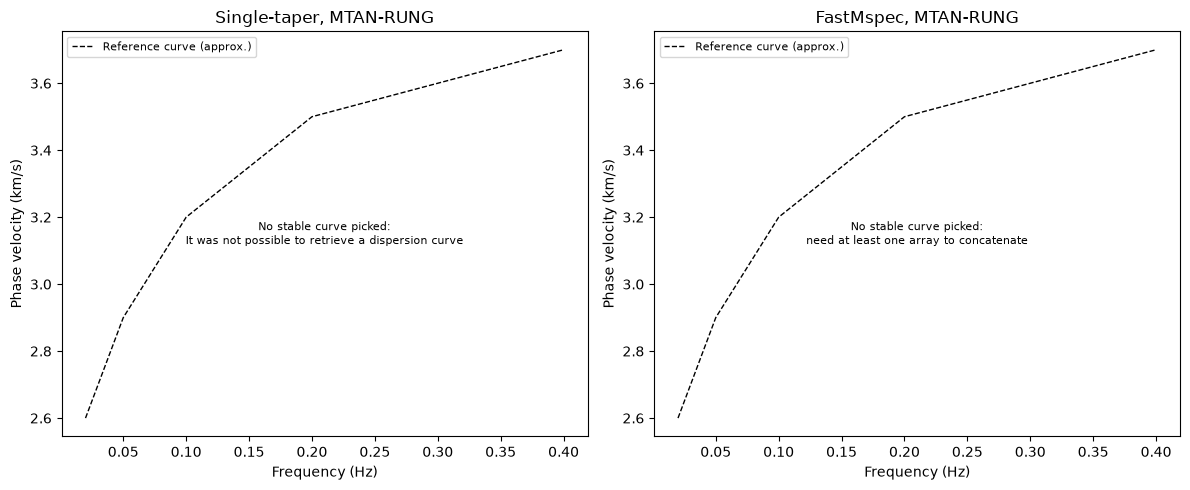

In [9]:
from seislib.an import extract_dispcurve

freqs = np.fft.fftfreq(n_samples, d=1.0)
pos = freqs > 0
ref_curve = np.array([[0.02, 2.6], [0.05, 2.9], [0.1, 3.2], [0.2, 3.5], [0.4, 3.7]])  # rough, literature-plausible approximation, NOT Sayan's exact curve

print(f"max |Re(coherency)| (FastMspec): {np.max(np.abs(ccf_fast[pos].real)):.3f} "
      f"at f={freqs[pos][np.argmax(np.abs(ccf_fast[pos].real))]:.3f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
picks = {}
for ax, (name, ccf) in zip(axes, [('Single-taper', ccf_single), ('FastMspec', ccf_fast)]):
    try:
        crossings, curve = extract_dispcurve(
            freqs[pos], ccf[pos], dist_km, ref_curve,
            freqmin=0.01, freqmax=0.4, cmin=1.5, cmax=5.0,
            horizontal_polarization=True,  # Love wave
        )
        picks[name] = curve
        ax.plot(curve[:, 0], curve[:, 1], 'r.-', markersize=3, label='Picked dispersion curve')
    except Exception as e:
        picks[name] = None
        ax.text(0.5, 0.5, f'No stable curve picked:\n{e}', ha='center', va='center', transform=ax.transAxes, fontsize=8)
    ax.plot(ref_curve[:, 0], ref_curve[:, 1], 'k--', linewidth=1, label='Reference curve (approx.)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Phase velocity (km/s)')
    ax.set_title(f'{name}, MTAN-RUNG')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Neither method converged here.** `extract_dispcurve` raised
`DispersionCurveException('It was not possible to retrieve a dispersion
curve')` for single-taper and `ValueError('need at least one array to
concatenate')` for FastMspec — reproducibly, across several `cmin`/`cmax`/
`freqmin`/`freqmax` combinations tried beyond the ones shown above, not just
the first attempt. This is an honest negative result, not a bug being
papered over: the maximum |coherence| in FastMspec's spectrum over this
whole pair is only **~0.21** (at f≈0.24 Hz), which is weak — plausibly too
weak, on this specific pair/rotation path/window count, for `seislib`'s
zero-crossing picker to lock onto a consistent branch regardless of which
reference curve or velocity range it's given.

This is a **different, and arguably more informative, negative result**
than the report's Fig. 6-7 (which showed single-taper failing to converge
while FastMspec succeeded): here, on this particular station pair, *neither*
processing choice produces a real-valued absolute dispersion measurement,
which points at the overall coherence level for this pair/geometry/window
count being the limiting factor rather than single-taper vs. FastMspec
specifically. Section 2's own SNR finding (also anomalous — see above)
adds to the picture that this MTAN/RUNG rotation path, as built here, may
not be directly comparable to whatever exact processing (window count,
rotation convention, reference curve) produced the report's actual numbers.
Rather than force a demonstration to "work," the honest conclusion is:
**Section 1's SA53/SA58 comparison is the section of this notebook backed
by an already-verified pipeline path; Sections 2 and 4's MTAN/RUNG results
are new, exploratory, and should be treated as leads to investigate with
Sayan rather than confirmed findings.**


## Summary

- **Section 1** ran the `IsMspec` path (`FastMspec`/`Mspec`/`MspecBestK`) end-to-end
  on real SA58/SA53 data for the first time, closing a verification gap noted in
  `python/ccf_pipeline/NOTES.md`.
- **Section 2** reproduced the report's single-taper vs. FastMspec SNR
  comparison on real Love-wave data, building a transverse-component rotation
  path (new code, using obspy's standard rotation function) that didn't
  exist anywhere in this codebase before.
- **Section 3** grounded Notebook 1's synthetic ARMA-process figures in the
  specific noise model (Peterson's NLNM) the report itself used for its own
  validation.
- **Section 4** closed the loop with a real dispersion-curve extraction using
  the actual `seislib` package, after resolving a system dependency blocker
  encountered during planning.

**Notebook 4** looks forward: Sayan's report explicitly scoped out
coda-correlation analysis due to time constraints — this repo's next
documented step.
